# Model Depth vs Validation

In [19]:
leak = 0.02 
num_steps_per_frame = 1
sparsity_frac = 0.9
min_length = 128 
max_length = 256 
min_num_blocks = 2 
max_num_blocks = 5 
block_overlap_depth = 1 
video_height = 128 
video_width = 128

batch_size = 1
device = "cuda"

import torch
import numpy as np
import matplotlib.pyplot as plt
from cube_model import cube

from computronium.video_utils import async_video_loader, video_data_generator
from tqdm import tqdm

@ torch.no_grad()
def get_loss_on_video_batch(data_np, 
                            num_blocks, length,
                            model: cube, 
                            num_steps_per_frame: int
                            ):
    data = torch.tensor(data_np, dtype=torch.float32).to(device)
    num_timesteps = data.shape[0]

    loss = 0
    MSE_total = 0.0
    for t in range(num_timesteps-1):
        x = data[t]

        for subtimestep in range(num_steps_per_frame): 
            y = model(x, instrument_correlations=None, num_blocks=num_blocks, length=length)

            model.Phi.append(model.Phi[-1]*(1-leak) + y * model.dt)
            model.Phi[-1][:, 0:3] *= 0 # zero out the first 3 channels in the prediction layer
            model.Phi[-1][:, 0:3] += y[:, 0:3] # set the first 3 channels to the absolute prediction (non-differential)

        _, MSE, _, _ = model.loss(data[t+1], y[:, 0:3], weight_regularization=0.0, activation_regularization=0.0)

        MSE_total += MSE
    
    loss = MSE_total / num_timesteps 
    return loss

model = cube(
    kernel_size=3, 
    num_channels_list=[16, 128, 16], 
    block_overlap_depth=1,
    device=device,
    leak=leak,
    dt=0.1,
    sparsity_frac=0.9).to(device)

model.load_model('../results/20240712.027/best_model.pth')

import os
import glob
val_paths = glob.glob(os.path.join('../dataset/debug/*.mp4'))
# add dataset to path

#val_paths = ['dataset/debug/LdcMthVbyek_000048_000058.mp4', 'dataset/debug/LdeKG4xz0uQ_000088_000098.mp4', 'dataset/debug/LddSWnpBzN8_000089_000099.mp4', 'dataset/debug/LdNJPIHY44Q_000014_000024.mp4', 'dataset/debug/LdZ8VK0kYtQ_000000_000010.mp4']
#val_paths = ["../" + p for p in val_paths]
num_blocks = 2
length = 128

val_losses = []
with torch.no_grad():
     
    for num_blocks in range(2, 10, 2):
        print(num_blocks)
        print(length)
        total_val_loss = 0
        cnt = 0
        for data_np_val in tqdm(video_data_generator(val_paths, 
                                                batch_size=batch_size, 
                                                num_workers=1, 
                                                rescale=[video_height, video_width], 
                                                float01=True)):
            model.Phi = []
            model.correlation_tensor = []
            val_loss = get_loss_on_video_batch(data_np_val, num_blocks, length, model, num_steps_per_frame)
            
            total_val_loss += val_loss.item()
            cnt += 1
            if cnt > (len(val_paths) // batch_size) + 1: 
                break
        print(total_val_loss)
        val_losses.append(total_val_loss)

2
128


43it [00:35,  1.21it/s]


2.20672938041389
4
128


43it [00:38,  1.10it/s]


2.2097897101193666
6
128


43it [00:40,  1.06it/s]


2.2092711124569178
8
128


43it [00:42,  1.02it/s]

2.2090408634394407


In [21]:
val_losses

[2.20672938041389, 2.2097897101193666, 2.2092711124569178, 2.2090408634394407]

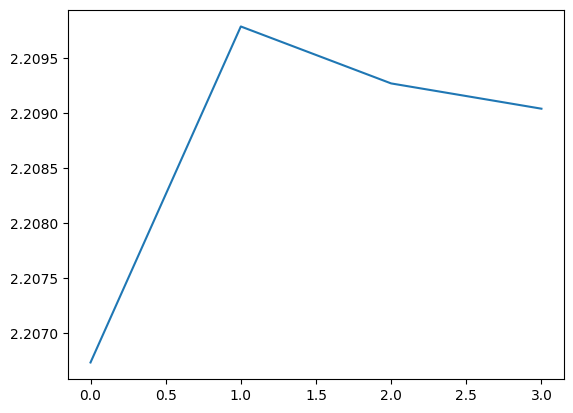

In [20]:
import matplotlib.pyplot as plt
plt.plot(val_losses)